# Metals Trade Mahalanobis Distance: Hourly And Daily

This notebook reuses the 5-minute trade-flow panel built from the 3-year raw metals trade archive, then resamples it to hourly and daily additive bars and recomputes Mahalanobis distance on trade-flow vectors.

Primary distance: EWMA Mahalanobis distance of signed-notional shares, where `B = +`, `A = -`, and `N = 0`, normalized by total complex notional in the bar. A second distance on unsigned notional participation shares is included as a concentration/control view.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantlab.metals_flow.anomaly import mahalanobis_distances

plt.style.use("seaborn-v0_8-whitegrid")

ROOTS = ["GC", "SI", "HG", "PL", "PA"]
SOURCE_ASSET_DIR = Path("assets/2026-06-25_metals_5m_trade_mahalanobis")
SOURCE_5M = SOURCE_ASSET_DIR / "metals_trade_flow_5m.parquet"
ASSET_DIR = Path("assets/2026-06-25_metals_trade_mahalanobis_hourly_daily")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

if not SOURCE_5M.exists():
    raise FileNotFoundError(
        f"Missing {SOURCE_5M}. Run 2026-06-25_metals_5m_trade_mahalanobis.ipynb first."
    )

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 80)

In [2]:
bars_5m = pd.read_parquet(SOURCE_5M)
bars_5m.index = pd.to_datetime(bars_5m.index, utc=True)
bars_5m = bars_5m.sort_index()

notional_cols = [f"{root}_notional" for root in ROOTS]
signed_cols = [f"{root}_signed_notional" for root in ROOTS]
trade_cols = [f"{root}_trades" for root in ROOTS]
contract_cols = [f"{root}_contracts" for root in ROOTS]
additive_cols = notional_cols + signed_cols + trade_cols + contract_cols

bars_5m[["complex_trades", "complex_contracts", "complex_notional"]].describe()

,complex_trades,complex_contracts,complex_notional
count,212363.000000,212363.000000,2.123630e+05
mean,722.020936,1224.796043,2.857230e+08
std,786.600616,1398.744731,3.647742e+08
min,9.000000,10.000000,1.274955e+06
25%,264.000000,425.000000,8.767962e+07
50%,473.000000,777.000000,1.728232e+08
75%,889.000000,1492.000000,3.437427e+08
max,24511.000000,36227.000000,1.570872e+10


## Helpers

In [3]:
def resample_trade_flow(frame: pd.DataFrame, frequency: str) -> pd.DataFrame:
    out = frame[additive_cols].resample(frequency).sum(min_count=1).fillna(0.0)
    out["complex_notional"] = out[notional_cols].sum(axis=1)
    out["complex_signed_notional"] = out[signed_cols].sum(axis=1)
    out["complex_trades"] = out[trade_cols].sum(axis=1)
    out["complex_contracts"] = out[contract_cols].sum(axis=1)
    return out.loc[out["complex_trades"] > 0].copy()


def flow_vectors(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    denominator = frame["complex_notional"].replace(0.0, np.nan)
    signed_flow_share = pd.DataFrame(index=frame.index)
    notional_share = pd.DataFrame(index=frame.index)
    for root in ROOTS:
        signed_flow_share[root] = frame[f"{root}_signed_notional"] / denominator
        notional_share[root] = frame[f"{root}_notional"] / denominator
    return (
        signed_flow_share.replace([np.inf, -np.inf], np.nan).fillna(0.0),
        notional_share.replace([np.inf, -np.inf], np.nan).fillna(0.0),
    )


def compute_md(frame: pd.DataFrame, *, halflife: int, min_periods: int) -> pd.DataFrame:
    signed_flow_share, notional_share = flow_vectors(frame)
    denominator = frame["complex_notional"].replace(0.0, np.nan)
    md = pd.DataFrame(index=frame.index)
    md["md_signed_flow_ewma"] = mahalanobis_distances(
        signed_flow_share,
        method="ewma",
        ewma_halflife=halflife,
        min_periods=min_periods,
        ridge=1e-6,
    )
    md["md_notional_share_ewma"] = mahalanobis_distances(
        notional_share,
        method="ewma",
        ewma_halflife=halflife,
        min_periods=min_periods,
        ridge=1e-6,
    )
    for column in ["md_signed_flow_ewma", "md_notional_share_ewma"]:
        valid = md[column].dropna()
        for quantile in [0.95, 0.99, 0.995]:
            md[f"{column}_q{int(quantile * 1000):03d}"] = valid.quantile(quantile)
    md["complex_trades"] = frame["complex_trades"]
    md["complex_notional"] = frame["complex_notional"]
    md["complex_signed_notional_ratio"] = frame["complex_signed_notional"] / denominator
    md = pd.concat(
        [
            md,
            signed_flow_share.add_prefix("signed_share_"),
            notional_share.add_prefix("notional_share_"),
        ],
        axis=1,
    )
    return md


def save_timeseries_plot(md: pd.DataFrame, title: str, path: Path) -> None:
    fig, ax = plt.subplots(figsize=(15, 5))
    md["md_signed_flow_ewma"].plot(ax=ax, linewidth=0.65, alpha=0.75, label="signed flow MD")
    ax.axhline(md["md_signed_flow_ewma_q950"].iloc[0], color="tab:orange", linestyle="--", linewidth=1, label="global q95")
    ax.axhline(md["md_signed_flow_ewma_q990"].iloc[0], color="tab:red", linestyle="--", linewidth=1, label="global q99")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("EWMA Mahalanobis distance")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()


def save_top_events(md: pd.DataFrame, path: Path) -> pd.DataFrame:
    top = md.sort_values("md_signed_flow_ewma", ascending=False).head(250)
    top.to_csv(path)
    return top

## Hourly Mahalanobis Distance

Hourly uses a one-week EWMA half-life: `168` hourly bars. The minimum warmup is the same.

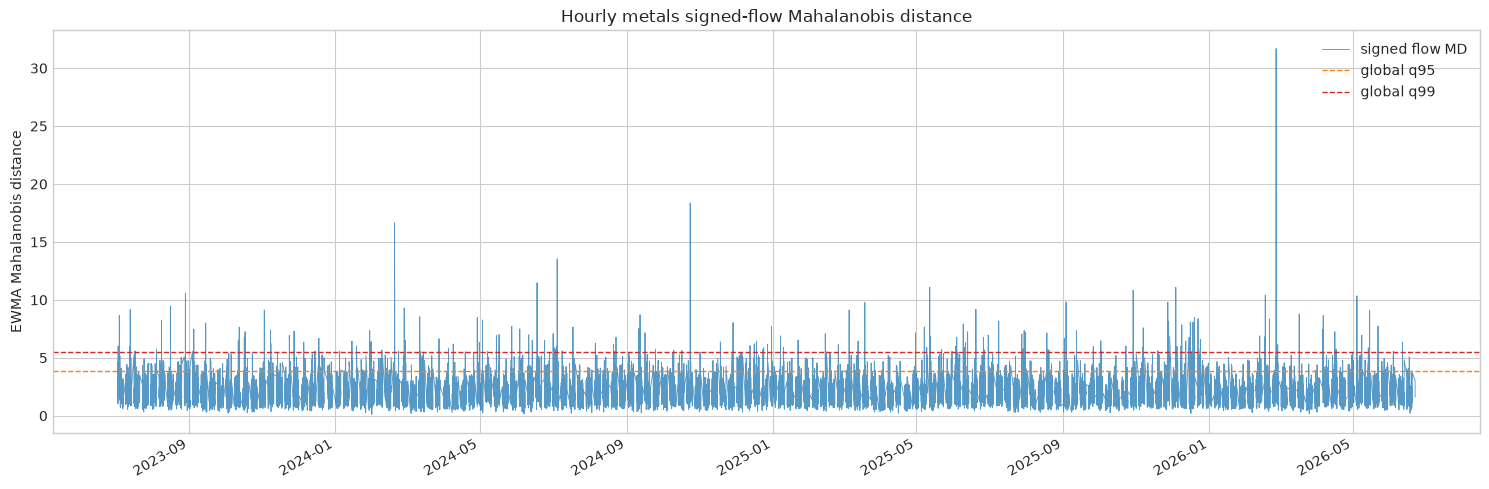

,md_signed_flow_ewma,md_notional_share_ewma,complex_trades,complex_signed_notional_ratio
count,17542.000000,17542.000000,17710.000000,17710.000000
mean,1.994111,1.763830,8657.850480,0.000157
std,1.083378,0.999876,7949.010522,0.049542
min,0.119809,0.121579,40.000000,-0.255119
50%,1.785476,1.531993,6104.000000,-0.000579
90%,3.249343,2.884087,18915.100000,0.061026
95%,3.874460,3.564611,24664.650000,0.082298
99%,5.492966,5.452620,38552.550000,0.125578
99.5%,6.660289,6.380225,44206.975000,0.141686
99.9%,9.152032,9.362184,59302.302000,0.190430


In [4]:
bars_1h = resample_trade_flow(bars_5m, "1h")
md_1h = compute_md(bars_1h, halflife=168, min_periods=168)

bars_1h.to_parquet(ASSET_DIR / "metals_trade_flow_1h.parquet")
md_1h.to_csv(ASSET_DIR / "trade_mahalanobis_1h.csv")
top_1h = save_top_events(md_1h, ASSET_DIR / "top_signed_flow_md_events_1h.csv")
save_timeseries_plot(md_1h, "Hourly metals signed-flow Mahalanobis distance", ASSET_DIR / "md_signed_flow_1h_timeseries.png")

md_1h[["md_signed_flow_ewma", "md_notional_share_ewma", "complex_trades", "complex_signed_notional_ratio"]].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.995, 0.999]
)

## Daily Mahalanobis Distance

Daily uses a 63-day EWMA half-life and warmup. A one-week daily covariance estimate is too unstable for a 5-dimensional flow vector, so this view is intentionally smoother.

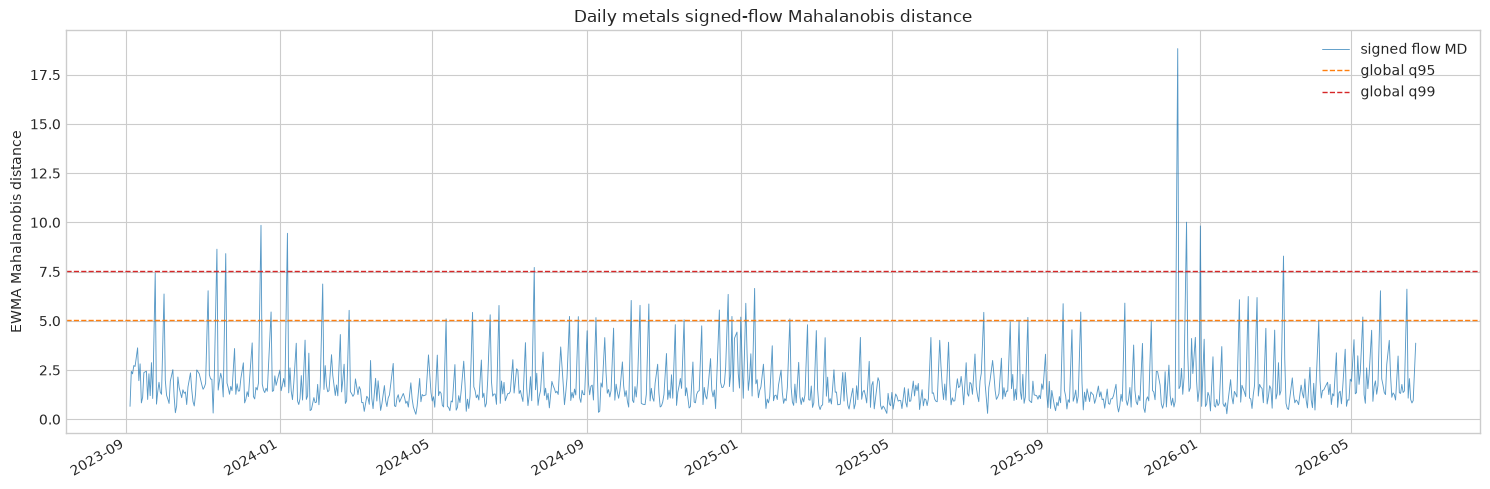

,md_signed_flow_ewma,md_notional_share_ewma,complex_trades,complex_signed_notional_ratio
count,871.000000,871.000000,934.000000,934.000000
mean,1.776548,1.870805,164165.451820,-0.002733
std,1.512909,1.005883,97134.416562,0.022753
min,0.249833,0.329547,1759.000000,-0.163509
50%,1.338241,1.647157,168919.500000,-0.002689
90%,3.357476,3.057665,266988.100000,0.018685
95%,5.026038,3.575997,316010.150000,0.028613
99%,7.512633,5.282363,459784.390000,0.071698
99.5%,9.163044,6.515125,520841.985000,0.088140
99.9%,11.155646,7.727603,694785.221000,0.116297


In [5]:
bars_1d = resample_trade_flow(bars_5m, "1D")
md_1d = compute_md(bars_1d, halflife=63, min_periods=63)

bars_1d.to_parquet(ASSET_DIR / "metals_trade_flow_1d.parquet")
md_1d.to_csv(ASSET_DIR / "trade_mahalanobis_1d.csv")
top_1d = save_top_events(md_1d, ASSET_DIR / "top_signed_flow_md_events_1d.csv")
save_timeseries_plot(md_1d, "Daily metals signed-flow Mahalanobis distance", ASSET_DIR / "md_signed_flow_1d_timeseries.png")

md_1d[["md_signed_flow_ewma", "md_notional_share_ewma", "complex_trades", "complex_signed_notional_ratio"]].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.995, 0.999]
)

## Top Events

In [6]:
display_cols = [
    "md_signed_flow_ewma",
    "md_notional_share_ewma",
    "complex_trades",
    "complex_notional",
    "complex_signed_notional_ratio",
    *[f"signed_share_{root}" for root in ROOTS],
    *[f"notional_share_{root}" for root in ROOTS],
]

top_1h[display_cols].head(20).style.format(
    {
        "md_signed_flow_ewma": "{:.2f}",
        "md_notional_share_ewma": "{:.2f}",
        "complex_trades": "{:.0f}",
        "complex_notional": "{:,.0f}",
        "complex_signed_notional_ratio": "{:.2%}",
        **{f"signed_share_{root}": "{:.2%}" for root in ROOTS},
        **{f"notional_share_{root}": "{:.2%}" for root in ROOTS},
    }
)

,md_signed_flow_ewma,md_notional_share_ewma,complex_trades,complex_notional,complex_signed_notional_ratio,signed_share_GC,signed_share_SI,signed_share_HG,signed_share_PL,signed_share_PA,notional_share_GC,notional_share_SI,notional_share_HG,notional_share_PL,notional_share_PA
ts,,,,,,,,,,,,,,,
2026-02-25 18:00:00+00:00,31.69,16.08,40,"10,784,272",-2.46%,19.39%,-4.25%,-15.43%,-2.16%,0.00%,38.77%,4.25%,46.16%,10.82%,0.00%
2024-10-23 23:00:00+00:00,18.35,7.60,2163,"676,594,672",9.01%,4.50%,1.96%,0.18%,0.04%,2.34%,70.97%,18.24%,3.94%,2.38%,4.47%
2024-02-19 19:00:00+00:00,16.64,8.26,342,"79,114,758",9.33%,8.70%,-4.37%,2.89%,-0.06%,2.17%,62.11%,20.09%,9.88%,3.10%,4.82%
2024-07-04 18:00:00+00:00,13.54,4.88,421,"104,369,082",4.25%,11.56%,-0.88%,-1.42%,-5.01%,0.00%,72.52%,7.64%,9.08%,10.37%,0.39%
2024-06-17 22:00:00+00:00,11.47,5.03,1083,"283,875,975",3.79%,-2.38%,1.15%,1.89%,3.01%,0.13%,60.05%,21.16%,11.42%,7.06%,0.32%
2025-12-03 21:00:00+00:00,11.07,5.19,2578,"1,214,619,398",-7.12%,-7.26%,-0.78%,-0.71%,1.90%,-0.28%,68.13%,19.87%,3.67%,5.45%,2.88%
2025-05-12 04:00:00+00:00,11.07,3.72,3382,"1,244,463,448",4.77%,2.85%,-0.15%,-0.08%,2.14%,0.00%,80.94%,11.29%,4.08%,3.55%,0.14%
2025-10-29 06:00:00+00:00,10.83,5.38,9137,"3,675,586,638",12.11%,6.37%,2.23%,3.47%,0.03%,0.01%,70.95%,14.71%,12.50%,1.53%,0.31%
2023-08-28 23:00:00+00:00,10.57,4.28,730,"216,748,210",6.97%,11.77%,-0.07%,-1.78%,-3.24%,0.29%,75.05%,8.17%,10.35%,6.03%,0.41%


In [7]:
top_1d[display_cols].head(20).style.format(
    {
        "md_signed_flow_ewma": "{:.2f}",
        "md_notional_share_ewma": "{:.2f}",
        "complex_trades": "{:.0f}",
        "complex_notional": "{:,.0f}",
        "complex_signed_notional_ratio": "{:.2%}",
        **{f"signed_share_{root}": "{:.2%}" for root in ROOTS},
        **{f"notional_share_{root}": "{:.2%}" for root in ROOTS},
    }
)

,md_signed_flow_ewma,md_notional_share_ewma,complex_trades,complex_notional,complex_signed_notional_ratio,signed_share_GC,signed_share_SI,signed_share_HG,signed_share_PL,signed_share_PA,notional_share_GC,notional_share_SI,notional_share_HG,notional_share_PL,notional_share_PA
ts,,,,,,,,,,,,,,,
2025-12-14 00:00:00+00:00,18.83,4.71,6065,"2,908,650,865",-6.84%,-6.42%,-0.76%,0.34%,0.55%,-0.54%,61.39%,31.01%,2.36%,3.42%,1.82%
2025-12-21 00:00:00+00:00,10.01,3.16,7743,"3,643,668,390",3.99%,1.85%,1.18%,0.09%,0.60%,0.27%,63.24%,28.15%,2.63%,4.40%,1.58%
2023-12-17 00:00:00+00:00,9.85,5.19,3014,"965,701,042",-4.28%,0.50%,-5.15%,0.64%,-0.04%,-0.23%,67.84%,19.98%,8.17%,2.38%,1.62%
2026-01-01 00:00:00+00:00,9.82,3.95,8775,"4,194,776,180",8.06%,3.74%,3.71%,0.35%,0.27%,-0.01%,42.74%,49.56%,3.46%,3.17%,1.08%
2024-01-07 00:00:00+00:00,9.45,11.97,2642,"787,176,792",-2.38%,-4.30%,-1.45%,3.24%,-0.27%,0.40%,69.31%,9.06%,16.05%,1.94%,3.63%
2023-11-12 00:00:00+00:00,8.64,1.82,3169,"839,645,180",-14.30%,-13.18%,-0.89%,-0.56%,0.30%,0.04%,76.73%,11.35%,8.61%,2.77%,0.54%
2023-11-19 00:00:00+00:00,8.41,4.38,2701,"848,750,562",-16.35%,-11.64%,-3.73%,-0.60%,-0.40%,0.03%,71.42%,16.43%,8.50%,2.37%,1.28%
2026-03-08 00:00:00+00:00,8.29,1.63,23943,"13,044,919,508",-3.28%,-2.01%,0.20%,-1.41%,-0.06%,0.00%,73.73%,16.28%,7.87%,1.66%,0.47%
2024-07-21 00:00:00+00:00,7.71,1.48,6955,"2,556,945,462",11.54%,9.03%,1.29%,0.68%,0.32%,0.21%,73.97%,11.14%,11.94%,2.18%,0.77%


## Event Counts

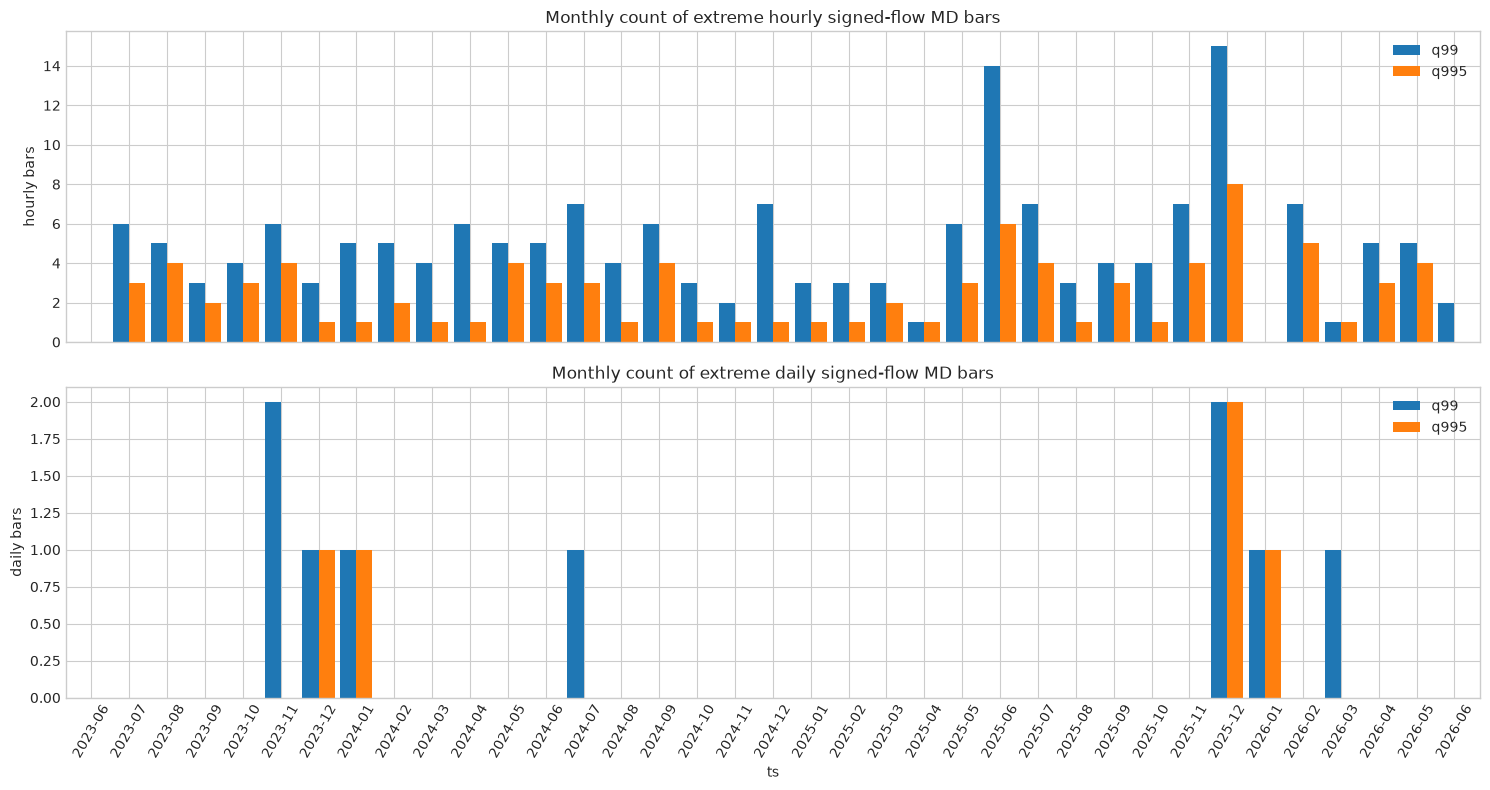

(         q95  q99  q995
 ts                     
 2025-07   32    7     4
 2025-08   11    3     1
 2025-09   17    4     3
 2025-10   13    4     1
 2025-11   30    7     4
 2025-12   44   15     8
 2026-01   12    0     0
 2026-02   35    7     5
 2026-03   13    1     1
 2026-04   35    5     3
 2026-05   28    5     4
 2026-06   10    2     0,
          q95  q99  q995
 ts                     
 2025-07    1    0     0
 2025-08    1    0     0
 2025-09    2    0     0
 2025-10    0    0     0
 2025-11    1    0     0
 2025-12    2    2     2
 2026-01    1    1     1
 2026-02    3    0     0
 2026-03    1    1     0
 2026-04    0    0     0
 2026-05    2    0     0
 2026-06    1    0     0)

In [8]:
def event_counts(md: pd.DataFrame, frequency: str) -> pd.DataFrame:
    flags = pd.DataFrame(index=md.index)
    flags["q95"] = md["md_signed_flow_ewma"] >= md["md_signed_flow_ewma_q950"].iloc[0]
    flags["q99"] = md["md_signed_flow_ewma"] >= md["md_signed_flow_ewma_q990"].iloc[0]
    flags["q995"] = md["md_signed_flow_ewma"] >= md["md_signed_flow_ewma_q995"].iloc[0]
    out = flags.resample(frequency).sum().astype(int)
    return out


hourly_monthly_counts = event_counts(md_1h, "ME")
daily_monthly_counts = event_counts(md_1d, "ME")
hourly_monthly_counts.index = hourly_monthly_counts.index.strftime("%Y-%m")
daily_monthly_counts.index = daily_monthly_counts.index.strftime("%Y-%m")
hourly_monthly_counts.to_csv(ASSET_DIR / "monthly_signed_flow_md_event_counts_1h.csv")
daily_monthly_counts.to_csv(ASSET_DIR / "monthly_signed_flow_md_event_counts_1d.csv")

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
hourly_monthly_counts[["q99", "q995"]].plot(kind="bar", ax=axes[0], width=0.85)
axes[0].set_title("Monthly count of extreme hourly signed-flow MD bars")
axes[0].set_ylabel("hourly bars")

daily_monthly_counts[["q99", "q995"]].plot(kind="bar", ax=axes[1], width=0.85)
axes[1].set_title("Monthly count of extreme daily signed-flow MD bars")
axes[1].set_ylabel("daily bars")
axes[1].tick_params(axis="x", labelrotation=60)

fig.tight_layout()
fig.savefig(ASSET_DIR / "monthly_signed_flow_md_event_counts_1h_1d.png", dpi=160)
plt.show()

hourly_monthly_counts.tail(12), daily_monthly_counts.tail(12)